<a href="https://colab.research.google.com/github/muhammetalicvs-prog/flyrank-ml/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Prioritizing Content for Human Review Using Search and Engagement Signals

## Abstract

This study asks whether historical search visibility, click-through, engagement, and content-update signals can be used to prioritize content records for human review. Using a public-safe anonymized dataset from the FlyRank ML Internship, I compared an interpretable fixed-rule baseline with Logistic Regression and Random Forest on a client-grouped holdout split. The methods were evaluated primarily with Precision@50 because the operational objective is to place useful candidates near the top of a limited review queue. The fixed-rule baseline achieved the strongest Precision@50, while Random Forest achieved the highest ROC-AUC, showing that broader discrimination and top-of-queue usefulness can lead to different model choices. The results support using an interpretable ranked queue as a human decision aid, but they do not prove that acting on the recommendations will improve business performance.

## 1. Question

*The research question and the decision it supports.*

## Research Question

Can historical search visibility, click-through, engagement, and content-update signals be used to rank content records that are more likely to require human review?

This research supports a content-review prioritization decision. The goal is not to automatically edit or remove content, but to create a small ranked queue so that reviewers can inspect the most promising candidates first.

The main operational objective is to maximize the number of useful candidates near the top of the review queue. For this reason, Precision@50 is treated as the primary evaluation metric, while ROC-AUC and Average Precision are used as supporting measures of broader ranking quality.

## 2. Data

This project uses the public-safe, anonymized dataset provided through the FlyRank ML Internship. The internship release was derived from approximately 79 million rows of production search and analytics data. For the modeling and ranking stages, I used the prepared `content_refresh_anonymized.csv` analysis table, which contains 30,000 content-level records and 44 columns.

The underlying data combines anonymized search-performance and web-analytics signals. Relevant fields include impressions, clicks, click-through rate, average search position, engagement measures, content freshness, and recent trend information. Client and content identifiers are hashed, and the analysis does not expose client names, page URLs, private search queries, or other identifying information.

For the forward-looking data-contract experiment, March 2026 was used as the feature window and April 2026 as the outcome window. The later modeling dataset uses prepared historical aggregates such as 30-day and 90-day performance measures supplied in the internship release.

The following fields were excluded from model features:

- Client and content identifiers, because they identify or group records rather than describe transferable behavior.
- Current- and previous-period values directly used to construct the target.
- `trend_direction` and `trend_pct`, because they directly reveal or closely approximate the label.
- Client names, URLs, search queries, and other private fields, which were not included in the public analysis output.
- Columns unavailable at the time a real review decision would be made.

These exclusions reduce identification risk, prevent target leakage, and keep the final research artifact safe for public deployment.


## 3. Methodology


### Assumptions

The project assumes that historical search visibility, click-through performance, engagement, content freshness, and recent behavior contain useful signals for prioritizing content for human review. The analysis does not assume that a high score proves that an edit will improve performance. It only estimates which records may be more useful to inspect first.

### Label Definition

The modeling target is a binary decline indicator created from future-period performance. A positive label represents a content record that declined in the defined outcome period. Features were restricted to information available before that outcome period.

### Features

The final modeling frame included public-safe numeric and categorical variables related to:

- Search impressions and clicks
- Click-through rate
- Average search position
- Engagement and session behavior
- Content age and time since last update
- Historical performance aggregates
- Public-safe content and client tiers

Identifiers and any fields that directly defined or closely reproduced the target were excluded.

### Baseline

The Week 4 fixed-rule baseline ranks records using an action score based on visible search demand, search position, weak click-through performance, and related opportunity signals. Each selected record also receives a reason code and a recommended human-review action.

The baseline is intentionally simple and interpretable. It provides a practical reference point for determining whether a more complex machine learning model creates a better top-ranked review queue.

### Models

Two supervised classification models were compared with the fixed-rule baseline:

1. Logistic Regression
2. Random Forest

The models produced probability scores that were used to rank test records from highest to lowest predicted risk.

### Validation Design

The data was split by client rather than by random row. The training set contained 23,837 records from 25 clients, while the test set contained 6,163 records from 7 different clients. There was no client overlap between the training and test sets.

This grouped holdout design provides a stricter test of whether the ranking approach generalizes to unseen clients.

### Evaluation Metrics

Precision@50 was selected as the primary operational metric because reviewers can inspect only a small number of records at one time. It measures how many of the first 50 recommendations are positive cases.

The analysis also reports:

- Precision@20
- Recall@50
- Average Precision
- ROC-AUC
- Test-set base rate

These metrics describe different aspects of ranking performance and should not be treated as interchangeable.

### Leakage Checks

Potential leakage and identification risks were reviewed before training. Identifier fields, direct label sources, label-construction proxies, and fields unavailable at decision time were excluded.

The validation audit also confirmed that client groups did not overlap between the training and test sets. This prevents the model from being evaluated on records from clients it had already seen during training.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## Results

All methods were evaluated on the same grouped test split containing 6,163 records from 7 unseen clients. The positive-class base rate in the test set was 0.511.

| Method | Precision@20 | Precision@50 | Recall@50 | Average Precision | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Week 4 fixed-rule baseline | 0.80 | 0.88 | 0.0140 | 0.5989 | 0.5618 |
| Logistic Regression | 0.70 | 0.64 | 0.0102 | 0.5691 | 0.5777 |
| Random Forest | 0.60 | 0.58 | 0.0092 | 0.5898 | 0.6111 |

### Main Finding

The Week 4 fixed-rule baseline achieved the strongest operational result, with a Precision@50 of 0.88. This means that 44 of the first 50 baseline recommendations were positive cases on the held-out test set.

Logistic Regression achieved a Precision@50 of 0.64, while Random Forest achieved 0.58. Therefore, neither machine learning model improved the primary top-of-queue metric over the fixed-rule baseline.

Random Forest achieved the highest ROC-AUC, at 0.6111. However, ROC-AUC measures discrimination across the full test set, while Precision@50 focuses on the small group of records that reviewers would inspect first. These metrics answer different questions.

Because the main operational objective is to place useful candidates near the top of a limited human-review queue, the fixed-rule baseline was retained as the preferred ranking approach.

### Interpretation

The result does not show that machine learning is generally ineffective. It shows that, for this dataset, split, label definition, and review capacity, the more complex models did not outperform the interpretable baseline on the metric most closely connected to the operational decision.

The output should be treated as a prioritization aid rather than proof that reviewing or editing a recommended record will improve business performance.

## 5. Limitations

*What this work cannot claim.*

## Limitations and Honest Framing

This study is an offline evaluation of ranking methods. It does not measure what happens after reviewers act on the recommendations, and it does not prove that editing a selected content record will improve traffic, engagement, or business outcomes.

The test-set positive rate was 0.511. Because the base rate is relatively high, top-of-queue precision should be interpreted together with the base rate and the other evaluation metrics.

The label is a proxy for future decline rather than a direct measure of whether a page should be refreshed. A positive label may reflect seasonality, changes in search demand, competition, technical issues, or other factors not represented in the dataset.

The dataset contains aggregated historical signals. It does not fully capture search intent, SERP layout, advertising activity, algorithm updates, content quality, competitor actions, or the cost and expected value of an intervention.

The fixed-rule thresholds and score weights were manually designed from observed patterns. They may require recalibration for a different time period, client group, market, or review capacity.

The client-grouped holdout provides a stronger validation design than a random row split, but the results still come from one prepared dataset and one test split. Performance may vary on future releases or in production.

The machine learning models were not extensively tuned, and the analysis does not establish that Logistic Regression or Random Forest are the best possible model families for this task.

Finally, the ranked queue supports human review. It should not automatically edit, remove, or publish content without additional investigation and editorial judgment.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## Ranked Recommendations

The final output is a ranked action playbook for human review. Records near the top of the queue combine stronger evidence of visibility, weaker click-through or engagement performance, and a clearer opportunity for investigation.

### Priority 1 — Review title and meta information

Use this action for pages that already receive meaningful search visibility but attract relatively few clicks.

Recommended checks:

- Compare the page title with the dominant search intent.
- Review the meta description for clarity and relevance.
- Check whether the snippet communicates a specific benefit.
- Inspect whether the page is competing with stronger SERP features or ads.

Expected use: editorial and SEO review, not automatic rewriting.

### Priority 2 — Refresh visible but aging content

Use this action for older pages that continue to receive impressions but show weak or declining performance.

Recommended checks:

- Verify whether facts, dates, examples, and screenshots remain current.
- Compare the page with newer competing content.
- Update sections that no longer answer the likely user need.
- Preserve useful sections rather than replacing the entire page without evidence.

Expected use: targeted content refresh after manual inspection.

### Priority 3 — Investigate engagement weakness

Use this action for records with visibility or clicks but weak downstream engagement.

Recommended checks:

- Confirm that the page satisfies the promise made in the search result.
- Review page structure, readability, internal links, and calls to action.
- Check for slow loading, layout issues, or distracting elements.
- Distinguish low engagement caused by content quality from low engagement caused by user intent.

Expected use: diagnostic review before making changes.

### Priority 4 — Reassess low-confidence candidates

Records with weaker evidence, limited impressions, or borderline scores should remain lower in the queue.

Recommended checks:

- Gather more observations before acting.
- Avoid prioritizing pages based on unstable percentages from very small volumes.
- Review seasonal or campaign-related context.
- Compare the cost of intervention with the expected value.

Expected use: monitoring or secondary review.

### Operating Recommendation

Use the fixed-rule baseline as the initial queue generator because it achieved the strongest Precision@50 on the held-out client split and remains easy to explain.

Review the top 50 records manually, document the action taken, and collect post-review outcomes. Those outcomes can later support threshold recalibration, improved labels, and a more reliable comparison between the baseline and future machine learning models.

The queue should be refreshed periodically rather than treated as a permanent ranking. Changes in demand, competition, content age, and search behavior may alter which records deserve attention.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Final evaluation results used in the research paper
results = pd.DataFrame({
    "Method": [
        "Week 4 fixed-rule baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision@20": [0.80, 0.70, 0.60],
    "Precision@50": [0.88, 0.64, 0.58],
    "Recall@50": [0.0140, 0.0102, 0.0092],
    "Average Precision": [0.5989, 0.5691, 0.5898],
    "ROC-AUC": [0.5618, 0.5777, 0.6111]
})

test_base_rate = 0.511

display(results.round(4))
print(f"Test-set base rate: {test_base_rate:.3f}")

,Method,Precision@20,Precision@50,Recall@50,Average Precision,ROC-AUC
0,Week 4 fixed-rule baseline,0.8,0.88,0.0140,0.5989,0.5618
1,Logistic Regression,0.7,0.64,0.0102,0.5691,0.5777
2,Random Forest,0.6,0.58,0.0092,0.5898,0.6111


Test-set base rate: 0.511


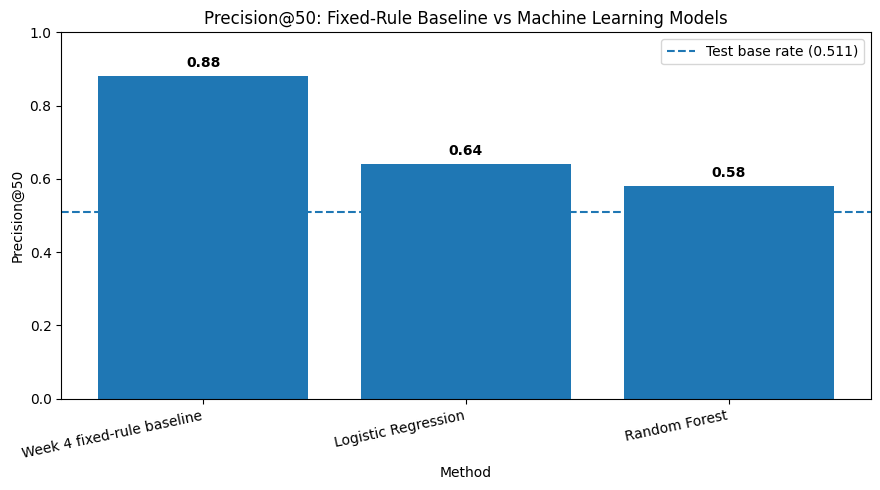

In [4]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    results["Method"],
    results["Precision@50"]
)

plt.axhline(
    test_base_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"Test base rate ({test_base_rate:.3f})"
)

plt.title("Precision@50: Fixed-Rule Baseline vs Machine Learning Models")
plt.ylabel("Precision@50")
plt.xlabel("Method")
plt.ylim(0, 1.0)
plt.xticks(rotation=12, ha="right")
plt.legend()

for bar, value in zip(bars, results["Precision@50"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.025,
        f"{value:.2f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig(
    "precision_at_50_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Reproducibility

The analysis can be inspected and rerun through the public project repository and its weekly notebooks.

- Repository: https://github.com/muhammetalicvs-prog/flyrank-ml
- Data contract: `work/notebooks/w03_data_contract.ipynb`
- Fixed-rule baseline: `work/notebooks/w04_baseline_score.ipynb`
- Model comparison: `work/notebooks/w05_model.ipynb`
- Validation audit: `work/notebooks/w06_validation_audit.ipynb`
- Action playbook: `work/notebooks/w07_action_playbook.ipynb`
- Capstone notebook: `work/notebooks/capstone.ipynb`

Random seeds, grouped validation decisions, excluded leakage fields, evaluation metrics, and final recommendation logic are documented in the notebooks.

## Acknowledgments and Data Credit

Built on the [FlyRank ML Internship dataset](https://flyrank.ai).

The project was completed as part of the FlyRank ML Internship. The dataset and project structure were supplied for educational research and portfolio development. All published outputs use anonymized, public-safe information.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.